In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
organizations_tmdb_tmdb_movie_metadata_path = kagglehub.dataset_download('organizations/tmdb/tmdb-movie-metadata')
rounakbanik_the_movies_dataset_path = kagglehub.dataset_download('rounakbanik/the-movies-dataset')

print('Data source import complete.')


# **Movie Recommendation System Using Content-Based and Collaborative Filtering**

## **Project Overview**
Sistem rekomendasi ini dikembangkan untuk memberikan rekomendasi film berdasarkan dua pendekatan utama:

1. **Content-Based Filtering**  
   - Menggunakan **TF-IDF Vectorization** dan **Cosine Similarity** untuk menemukan film yang memiliki kemiripan berdasarkan metadata seperti genre, sutradara, dan kata kunci.
   - Pendekatan ini cocok untuk pengguna yang ingin menemukan film serupa dengan yang telah mereka tonton.
   - Model dievaluasi dengan **NDCG@10 (Normalized Discounted Cumulative Gain)** untuk mengukur akurasi prediksi.

2. **Collaborative Filtering (Matrix Factorization - SVD)**  
   - Menggunakan teknik **Singular Value Decomposition (SVD)** untuk memprediksi rating film berdasarkan interaksi pengguna sebelumnya.
   - Pendekatan ini bekerja dengan menganalisis pola rating pengguna lain yang memiliki preferensi serupa.
   - Model dievaluasi dengan **Root Mean Square Error (RMSE)** dan **Mean Absolute Error (MAE)** untuk mengukur akurasi prediksi.

## **Load Dataset**


In [ ]:
# Import library yang diperlukan
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
from collections import Counter
from sklearn.metrics import ndcg_score
from surprise import Reader, Dataset, SVD
from sklearn.metrics.pairwise import linear_kernel
from surprise.model_selection import cross_validate
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Membaca dataset
credits_df = pd.read_csv('../input/tmdb-movie-metadata/tmdb_5000_credits.csv')
movies_df = pd.read_csv('../input/tmdb-movie-metadata/tmdb_5000_movies.csv')
ratings_df = pd.read_csv('../input/the-movies-dataset/ratings_small.csv')     # Data tentang rating pengguna

## **Data Understanding**

 Pada tahap **Data Understanding**, kita mengeksplorasi tiga dataset utama: **movies**, **credits**, dan **ratings**. Informasi umum dari masing-masing dataset ditampilkan untuk memahami struktur, jumlah data, serta tipe variabel yang tersedia. Setelah itu, dilakukan penggabungan dataset **movies** dan **credits** berdasarkan kolom **id** untuk menyatukan informasi pemeran dan kru film.  

Statistik deskriptif digunakan untuk mendapatkan insight awal, seperti rata-rata vote, durasi film terpanjang, serta film dengan pendapatan tertinggi. Visualisasi dilakukan untuk menganalisis distribusi vote dan rating pengguna, hubungan antara popularitas dan pendapatan film, jumlah film berdasarkan bahasa asli, serta korelasi antara runtime dan vote average. Selain itu, perusahaan produksi dengan jumlah film terbanyak juga dianalisis. Terakhir, heatmap korelasi digunakan untuk memahami hubungan antar variabel penting dalam dataset.

In [ ]:
# ==================== Analisis DataFrame movies_df ====================

# 1. Jumlah data (baris dan kolom)
print("📌 Jumlah baris dan kolom (movies_df):")
print(movies_df.shape)
print()

# 2. Kondisi data
print("📌 Informasi struktur data (movies_df):")
print(movies_df.info())
print()

print("📌 Jumlah missing value tiap kolom (movies_df):")
print(movies_df.isnull().sum())
print()

print("📌 Jumlah data duplikat (movies_df):")
print(movies_df.drop(columns=['genres'], errors='ignore').duplicated().sum())  # Hindari error karena kolom list
print()

# 3. Statistik numerik
print("📌 Statistik deskriptif numerik (movies_df):")
print(movies_df.describe(include='number'))
print()


# ==================== Analisis DataFrame credits_df ====================

print("📌 Jumlah baris dan kolom (credits_df):")
print(credits_df.shape)
print()

print("📌 Informasi struktur data (credits_df):")
print(credits_df.info())
print()

print("📌 Jumlah missing value tiap kolom (credits_df):")
print(credits_df.isnull().sum())
print()

print("📌 Jumlah data duplikat (credits_df):")
print(credits_df.drop(columns=['cast', 'crew'], errors='ignore').duplicated().sum())
print()

print("📌 Statistik deskriptif numerik (credits_df):")
print(credits_df.describe(include='number'))
print()


# ==================== Analisis DataFrame ratings_df ====================

print("📌 Jumlah baris dan kolom (ratings_df):")
print(ratings_df.shape)
print()

print("📌 Informasi struktur data (ratings_df):")
print(ratings_df.info())
print()

print("📌 Jumlah missing value tiap kolom (ratings_df):")
print(ratings_df.isnull().sum())
print()

print("📌 Jumlah data duplikat (ratings_df):")
print(ratings_df.duplicated().sum())
print()

print("📌 Statistik deskriptif numerik (ratings_df):")
print(ratings_df.describe(include='number'))
print()


📌 Jumlah baris dan kolom (movies_df):
(4803, 20)

📌 Informasi struktur data (movies_df):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-nul

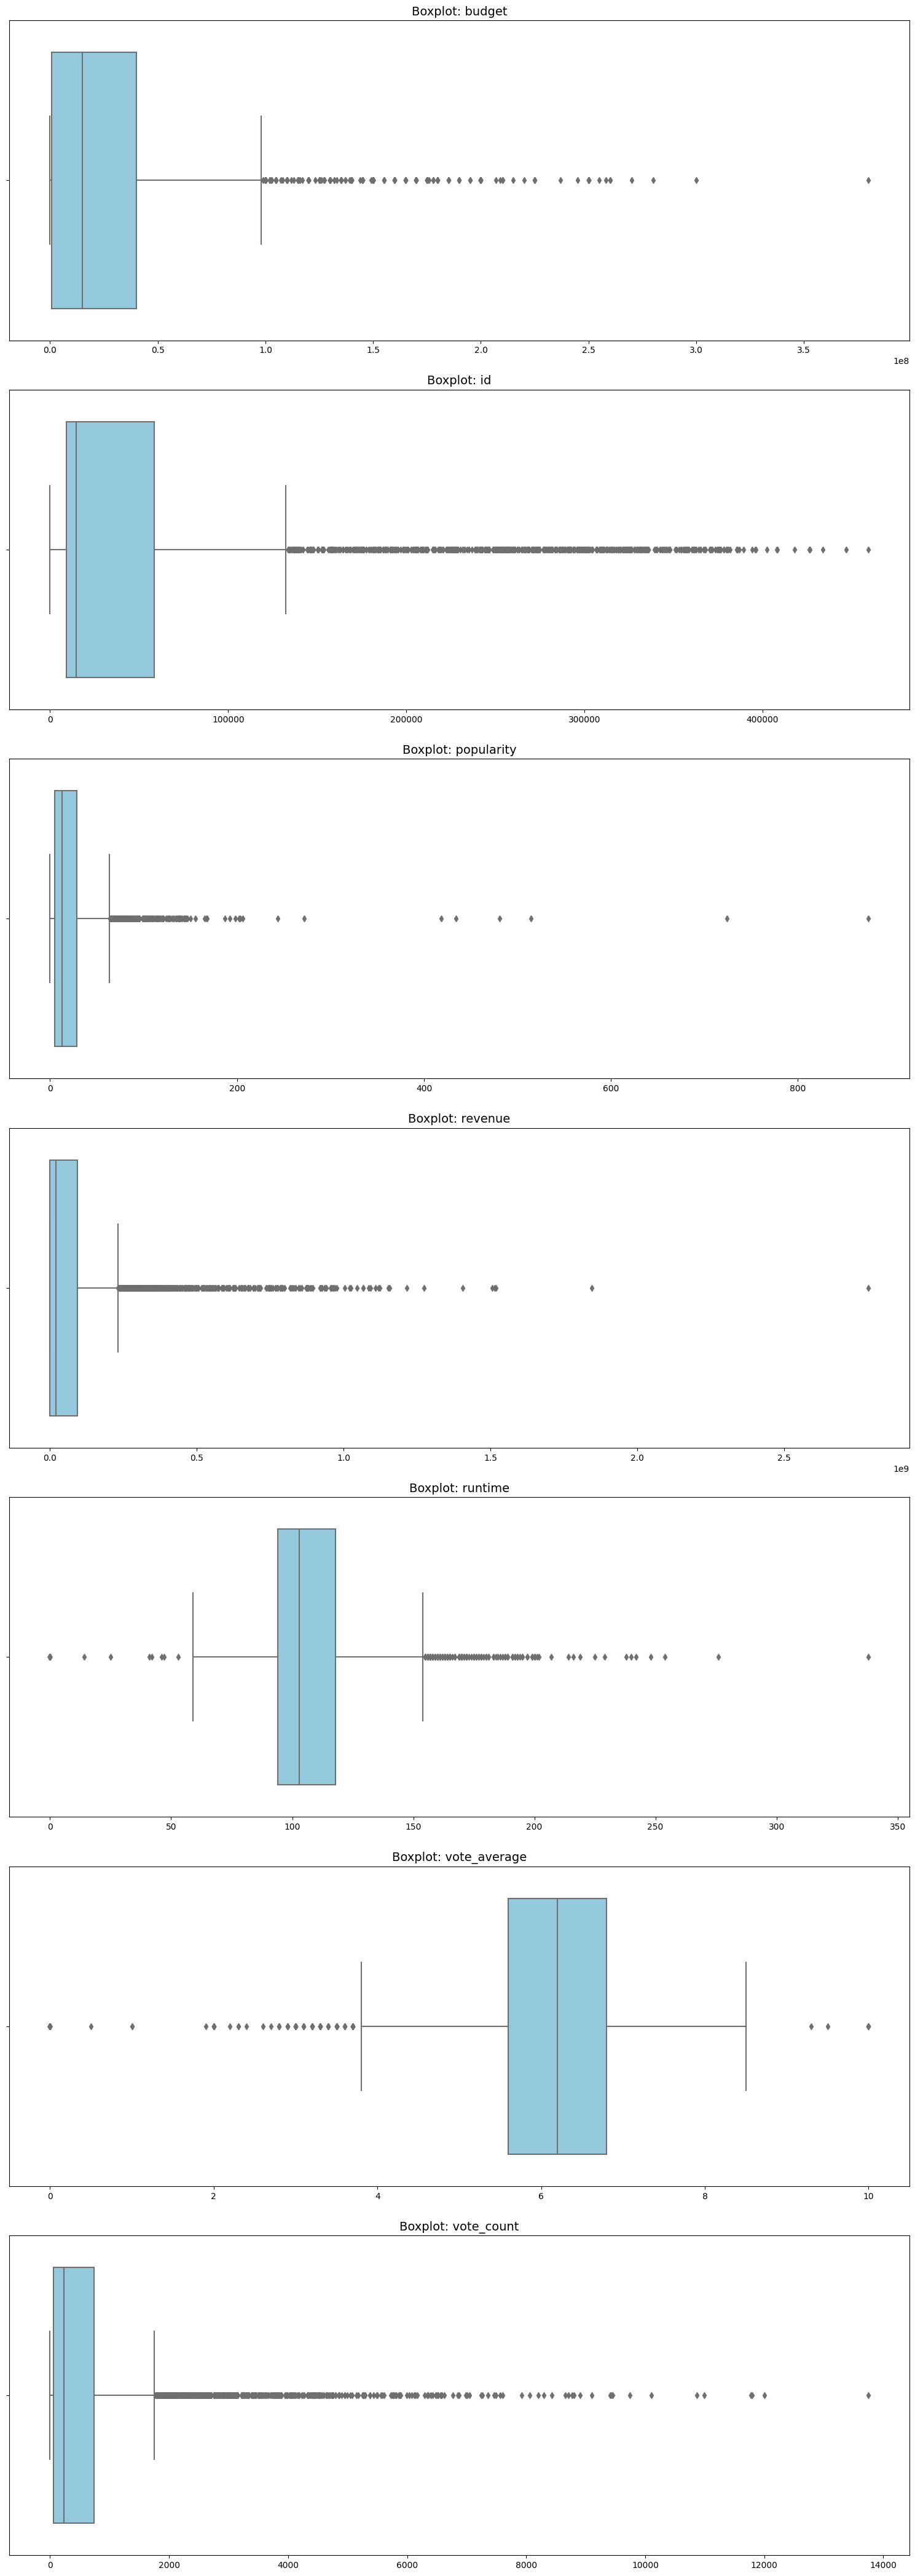

In [ ]:
# Pilih hanya kolom numerik dari movies_df
numeric_cols = movies_df.select_dtypes(include=['float64', 'int64']).columns

# Ukuran plot
plt.figure(figsize=(15, 6 * len(numeric_cols)))

# Loop dan buat boxplot untuk tiap kolom numerik
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(data=movies_df, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=14)
    plt.xlabel('')

plt.tight_layout()
plt.show()

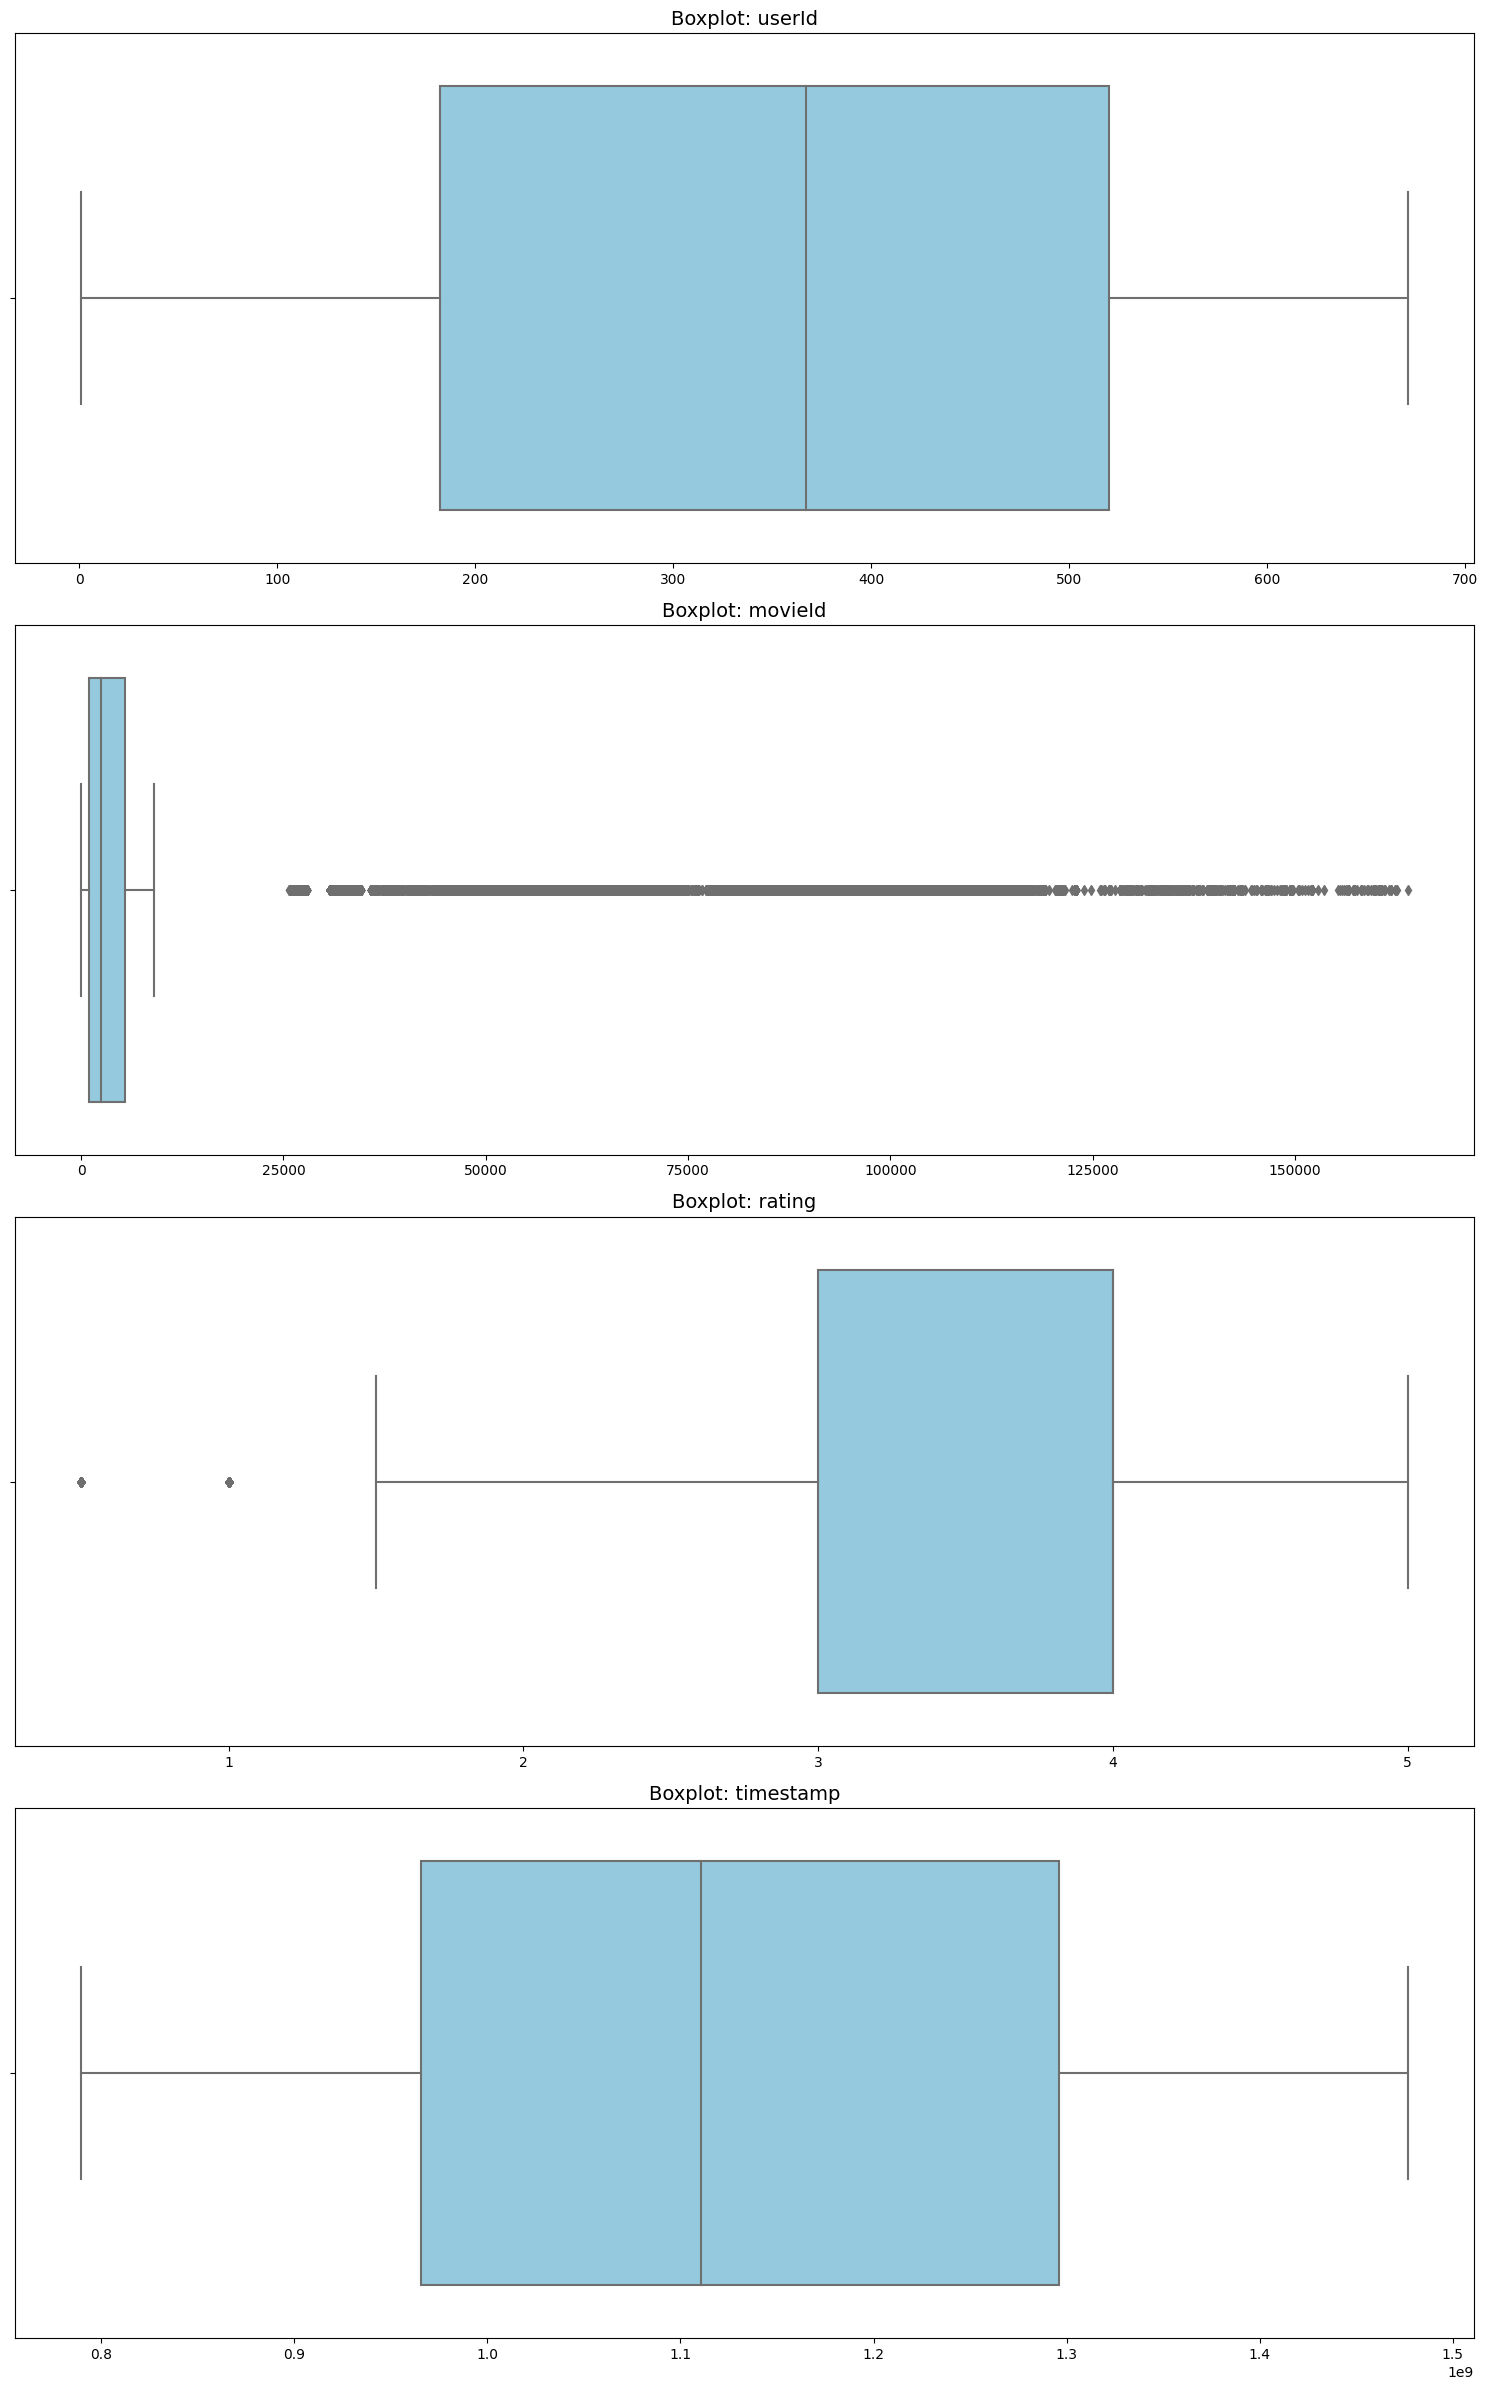

In [ ]:
# Pilih hanya kolom numerik dari ratings_df
numeric_cols = ratings_df.select_dtypes(include=['float64', 'int64']).columns

# Ukuran plot
plt.figure(figsize=(15, 6 * len(numeric_cols)))

# Loop dan buat boxplot untuk tiap kolom numerik
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(data=ratings_df, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}', fontsize=14)
    plt.xlabel('')

plt.tight_layout()
plt.show()


In [ ]:
# Menampilkan informasi umum dataset
print("\nInformasi Dataset Film:")
print(movies_df.info())


Informasi Dataset Film:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 

In [ ]:
# Menampilkan informasi umum dataset
print("\nInformasi Dataset Credit:")
print(credits_df.info())


Informasi Dataset Credit:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  4803 non-null   int64 
 1   title     4803 non-null   object
 2   cast      4803 non-null   object
 3   crew      4803 non-null   object
dtypes: int64(1), object(3)
memory usage: 150.2+ KB
None


In [ ]:
print("\nInformasi Dataset Rating:")
print(ratings_df.info())


Informasi Dataset Rating:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None


### **Informasi Dataset Film, Kredit, dan Rating**

#### **Dataset Film (`movies_df`)**
Dataset ini berisi informasi terkait berbagai film, termasuk anggaran, genre, dan rating pengguna.

##### **Kolom dalam Dataset:**
| No | Nama Kolom             | Tipe Data | Deskripsi |
|----|------------------------|----------|-----------|
| 1  | `budget`               | int64    | Total anggaran produksi film. |
| 2  | `genres`               | object   | Daftar genre film dalam format list atau string. |
| 3  | `homepage`             | object   | URL situs resmi film. |
| 4  | `id`                   | int64    | ID unik film (terhubung dengan dataset lain). |
| 5  | `keywords`             | object   | Kata kunci atau tag yang mendeskripsikan film. |
| 6  | `original_language`    | object   | Bahasa asli film. |
| 7  | `original_title`       | object   | Judul asli film sebelum diterjemahkan. |
| 8  | `overview`             | object   | Ringkasan singkat cerita film. |
| 9  | `popularity`           | float64  | Skor numerik yang mengindikasikan popularitas film. |
| 10 | `production_companies` | object   | Nama perusahaan produksi film. |
| 11 | `production_countries` | object   | Negara tempat film diproduksi. |
| 12 | `release_date`         | object   | Tanggal rilis film. |
| 13 | `revenue`              | int64    | Total pendapatan yang dihasilkan film. |
| 14 | `runtime`              | float64  | Durasi film dalam menit. |
| 15 | `spoken_languages`     | object   | Bahasa yang digunakan dalam film. |
| 16 | `status`               | object   | Status film (contoh: "Released", "Rumored"). |
| 17 | `tagline`              | object   | Slogan atau tagline resmi film. |
| 18 | `title`                | object   | Judul resmi film. |
| 19 | `vote_average`         | float64  | Nilai rata-rata rating film berdasarkan ulasan pengguna. |
| 20 | `vote_count`           | int64    | Jumlah total ulasan yang diberikan pengguna. |

---

#### **Dataset Kredit (`credits_df`)**
Dataset ini berisi informasi mengenai pemeran dan kru film.

##### **Kolom dalam Dataset:**
| No | Nama Kolom | Tipe Data | Deskripsi |
|----|-----------|----------|-----------|
| 1  | `movie_id` | int64   | ID unik film yang berhubungan dengan dataset `movies_df`. |
| 2  | `title`    | object  | Judul film. |
| 3  | `cast`     | object  | Daftar aktor utama dan pemeran pendukung. |
| 4  | `crew`     | object  | Daftar kru film, termasuk sutradara dan penulis. |

---

#### **Dataset Rating (`ratings_df`)**
Dataset ini berisi informasi rating yang diberikan oleh pengguna terhadap film tertentu.

##### **Kolom dalam Dataset:**
| No | Nama Kolom  | Tipe Data | Deskripsi |
|----|------------|----------|-----------|
| 1  | `userId`   | int64    | ID unik pengguna yang memberikan rating. |
| 2  | `movieId`  | int64    | ID unik film yang diberikan rating (terhubung dengan `movies_df`). |
| 3  | `rating`   | float64  | Skor rating yang diberikan oleh pengguna (biasanya dalam rentang 1-5). |
| 4  | `timestamp`| int64    | Waktu saat pengguna memberikan rating (format Unix Timestamp). |


In [ ]:
# Menampilkan ringkasan statistik data numerik
print("\nRingkasan Statistik Dataset Film:")
print(movies_df.describe())


Ringkasan Statistik Dataset Film:
             budget             id   popularity       revenue      runtime  \
count  4.803000e+03    4803.000000  4803.000000  4.803000e+03  4801.000000   
mean   2.904504e+07   57165.484281    21.492301  8.226064e+07   106.875859   
std    4.072239e+07   88694.614033    31.816650  1.628571e+08    22.611935   
min    0.000000e+00       5.000000     0.000000  0.000000e+00     0.000000   
25%    7.900000e+05    9014.500000     4.668070  0.000000e+00    94.000000   
50%    1.500000e+07   14629.000000    12.921594  1.917000e+07   103.000000   
75%    4.000000e+07   58610.500000    28.313505  9.291719e+07   118.000000   
max    3.800000e+08  459488.000000   875.581305  2.787965e+09   338.000000   

       vote_average    vote_count  
count   4803.000000   4803.000000  
mean       6.092172    690.217989  
std        1.194612   1234.585891  
min        0.000000      0.000000  
25%        5.600000     54.000000  
50%        6.200000    235.000000  
75%       

In [ ]:

print("\nRingkasan Statistik Dataset Rating:")
print(ratings_df.describe())


Ringkasan Statistik Dataset Rating:
              userId        movieId         rating     timestamp
count  100004.000000  100004.000000  100004.000000  1.000040e+05
mean      347.011310   12548.664363       3.543608  1.129639e+09
std       195.163838   26369.198969       1.058064  1.916858e+08
min         1.000000       1.000000       0.500000  7.896520e+08
25%       182.000000    1028.000000       3.000000  9.658478e+08
50%       367.000000    2406.500000       4.000000  1.110422e+09
75%       520.000000    5418.000000       4.000000  1.296192e+09
max       671.000000  163949.000000       5.000000  1.476641e+09


In [ ]:
# Mengubah nama kolom untuk konsistensi
credits_df.columns = ['id', 'title', 'cast', 'crew']

# Melakukan merge berdasarkan kolom 'id' untuk menghindari duplikasi judul
movies_df = movies_df.merge(credits_df, on='id')

# Menghapus salah satu kolom title yang duplikat (misalnya, 'title_y')
movies_df = movies_df.drop(columns=['title_y'])

# Mengganti nama 'title_x' kembali menjadi 'title' agar lebih jelas
movies_df = movies_df.rename(columns={'title_x': 'title'})

# Menampilkan informasi dataset hasil merge
print(movies_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [ ]:
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
print("\nInsight dari Statistik Deskriptif:")
print(f"- Rata-rata vote film: {movies_df['vote_average'].mean():.2f}")
print(f"- Durasi film terpanjang: {movies_df['runtime'].max()} menit")
print(f"- Film dengan pendapatan tertinggi: {movies_df.loc[movies_df['revenue'].idxmax(), 'title']} dengan pendapatan ${movies_df['revenue'].max():,.2f}")


Insight dari Statistik Deskriptif:
- Rata-rata vote film: 6.09
- Durasi film terpanjang: 338.0 menit
- Film dengan pendapatan tertinggi: Avatar dengan pendapatan $2,787,965,087.00


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


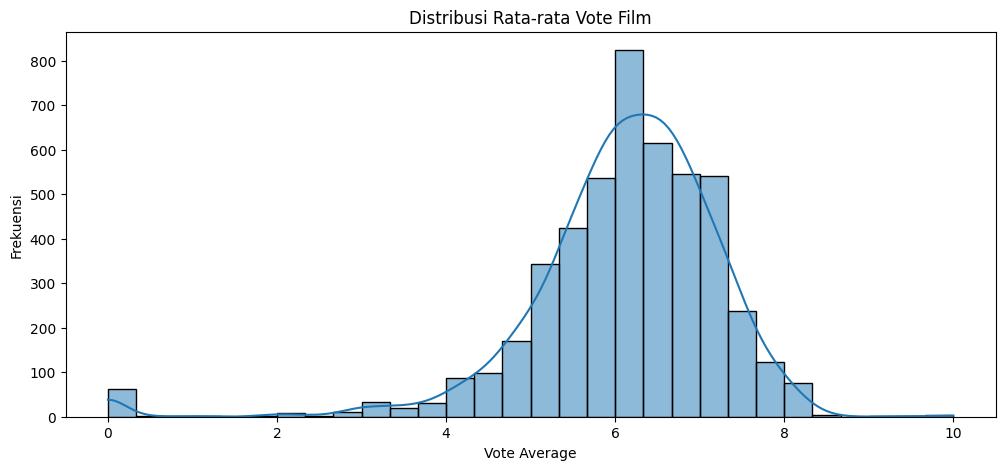

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(movies_df['vote_average'].dropna(), bins=30, kde=True)
plt.title("Distribusi Rata-rata Vote Film")
plt.xlabel("Vote Average")
plt.ylabel("Frekuensi")
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


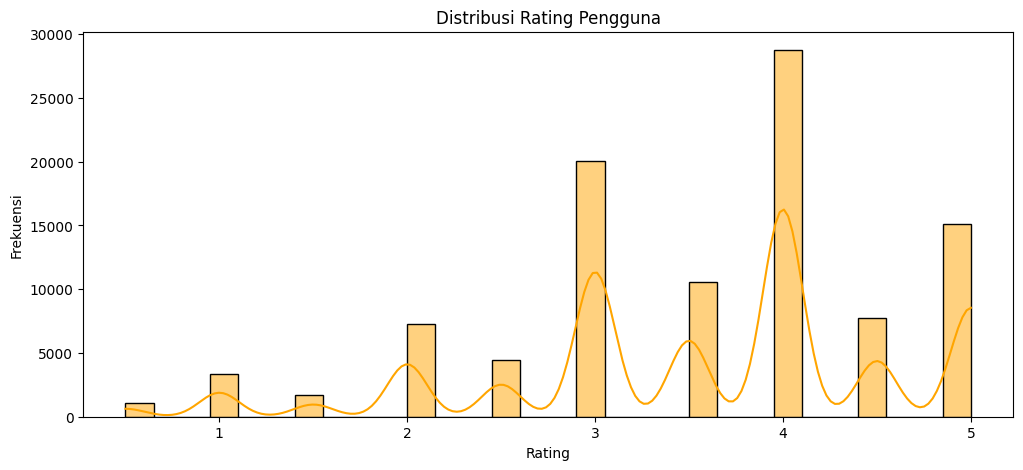

In [ ]:
plt.figure(figsize=(12,5))
sns.histplot(ratings_df['rating'].dropna(), bins=30, kde=True, color='orange')
plt.title("Distribusi Rating Pengguna")
plt.xlabel("Rating")
plt.ylabel("Frekuensi")
plt.show()

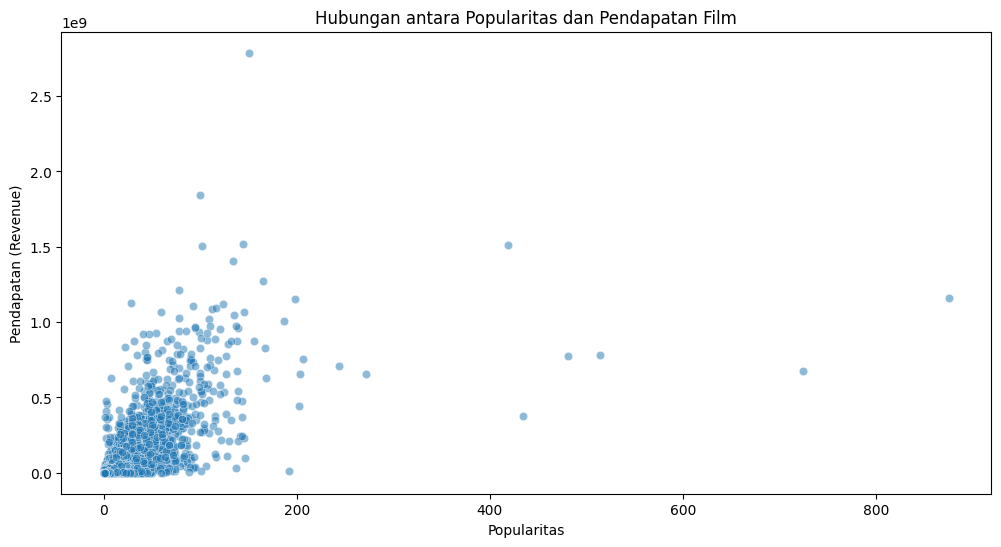

In [ ]:
# Visualisasi hubungan antara popularitas dan pendapatan film
plt.figure(figsize=(12,6))
sns.scatterplot(data=movies_df, x='popularity', y='revenue', alpha=0.5)
plt.title("Hubungan antara Popularitas dan Pendapatan Film")
plt.xlabel("Popularitas")
plt.ylabel("Pendapatan (Revenue)")
plt.show()

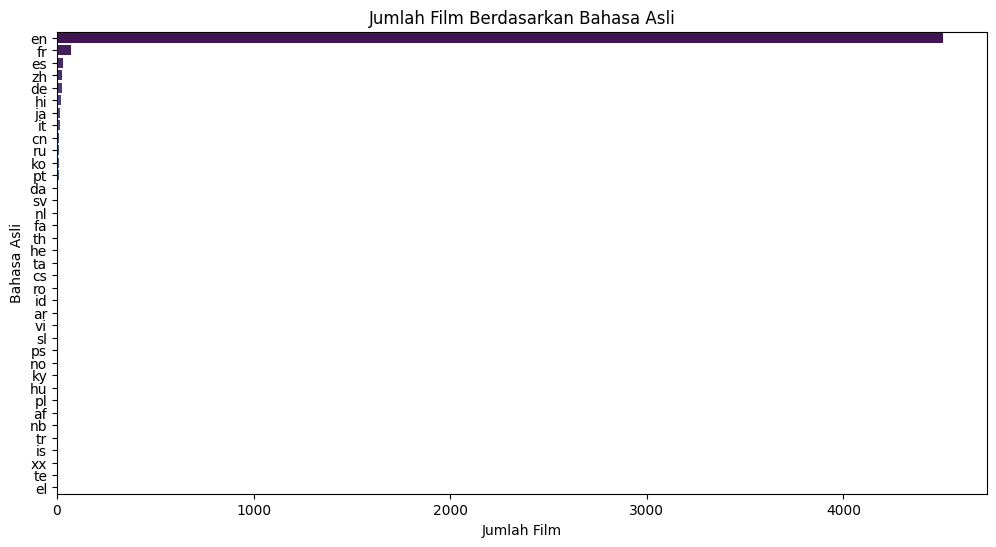

In [ ]:
# Visualisasi jumlah film berdasarkan bahasa asli
plt.figure(figsize=(12,6))
sns.countplot(y=movies_df['original_language'], order=movies_df['original_language'].value_counts().index, palette='viridis')
plt.title("Jumlah Film Berdasarkan Bahasa Asli")
plt.xlabel("Jumlah Film")
plt.ylabel("Bahasa Asli")
plt.show()

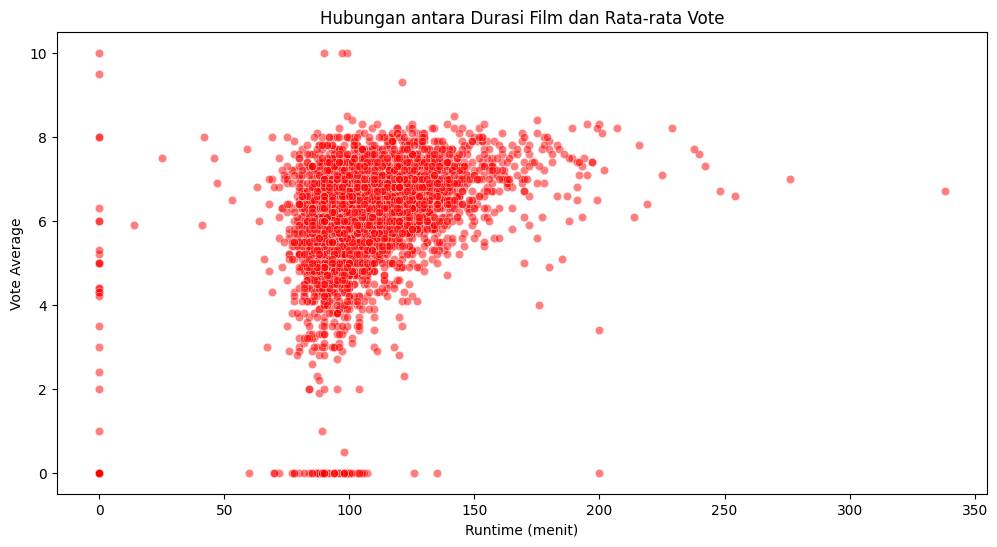

In [ ]:
# Visualisasi hubungan antara runtime dan vote_average
plt.figure(figsize=(12,6))
sns.scatterplot(data=movies_df, x='runtime', y='vote_average', alpha=0.5, color='red')
plt.title("Hubungan antara Durasi Film dan Rata-rata Vote")
plt.xlabel("Runtime (menit)")
plt.ylabel("Vote Average")
plt.show()

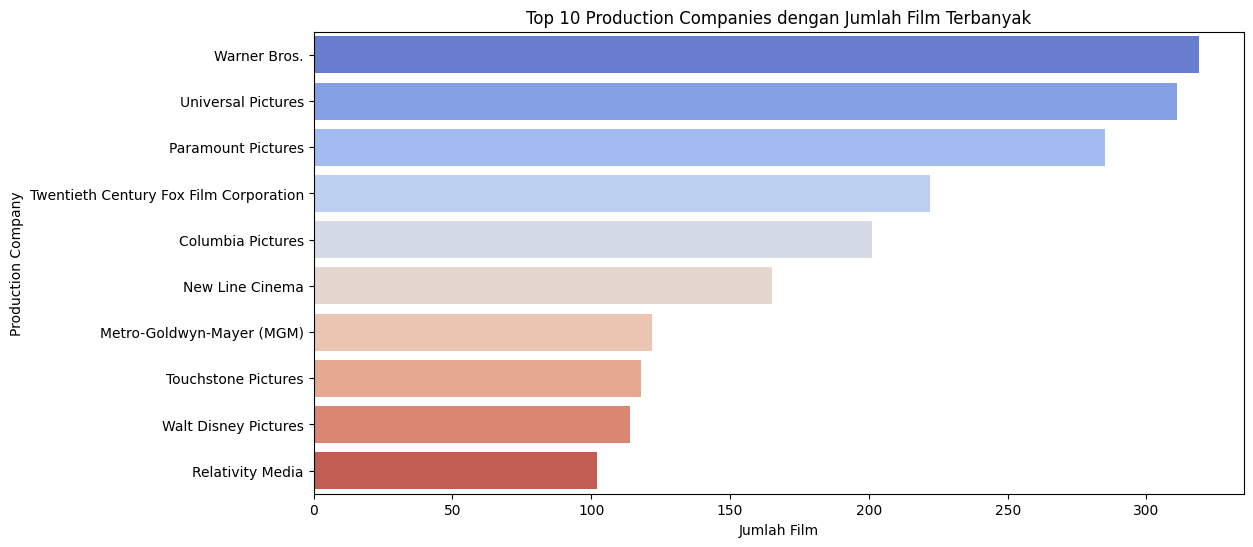

In [ ]:
# Visualisasi top 10 production companies dengan jumlah film terbanyak
# Mengambil data perusahaan produksi
production_companies = movies_df['production_companies'].dropna().apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if isinstance(x, str) else [])
all_companies = [company for sublist in production_companies for company in sublist]
top_companies = pd.DataFrame(Counter(all_companies).most_common(10), columns=['Company', 'Film Count'])

plt.figure(figsize=(12,6))
sns.barplot(data=top_companies, x='Film Count', y='Company', palette='coolwarm')
plt.title("Top 10 Production Companies dengan Jumlah Film Terbanyak")
plt.xlabel("Jumlah Film")
plt.ylabel("Production Company")
plt.show()

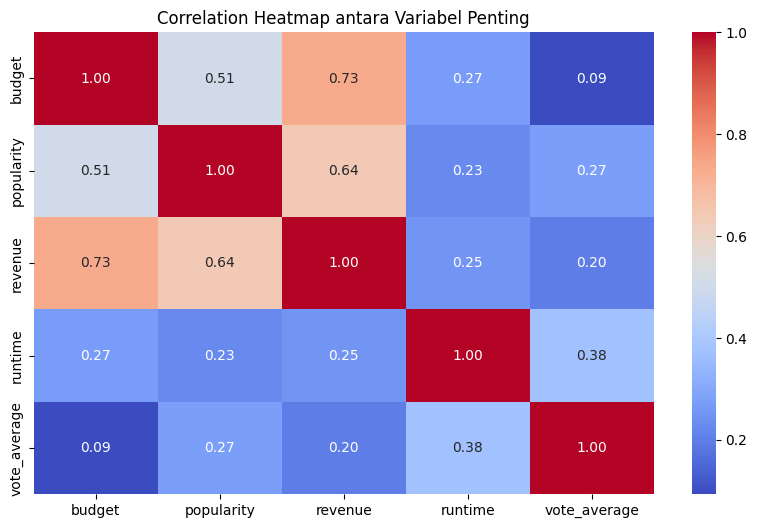

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(movies_df[['budget', 'popularity', 'revenue', 'runtime', 'vote_average']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap antara Variabel Penting")
plt.show()

**Insight dari Visualisasi Data Film**

**1. Hubungan antara Popularitas dan Pendapatan Film**
- Film dengan popularitas tinggi cenderung memiliki pendapatan lebih besar, meskipun ada beberapa outlier yang menghasilkan pendapatan tinggi meskipun popularitasnya sedang.  
- Sebagian besar film memiliki popularitas rendah hingga sedang, dengan pendapatan yang relatif kecil.  

**2. Distribusi Rata-rata Vote Film**
- Distribusi rating cenderung normal dengan puncak pada nilai **6-7**, menunjukkan bahwa sebagian besar film dinilai cukup baik.  
- Rating sangat rendah (<2) dan sangat tinggi (>9) jarang terjadi.  

**3. Distribusi Rating Pengguna**
- Mayoritas rating berkisar antara **3-5**, dengan puncak pada **4**, mengindikasikan kepuasan pengguna.  
- Rating di bawah 3 lebih jarang terjadi, menunjukkan sedikit film yang benar-benar buruk menurut pengguna.  

**4. Correlation Heatmap**
- **Budget dan revenue (0.73)** serta **popularity dan revenue (0.64)** menunjukkan hubungan kuat, artinya film dengan anggaran besar dan popularitas tinggi cenderung menghasilkan lebih banyak pendapatan.  
- **Budget dan popularity (0.51)** memiliki korelasi moderat, menandakan bahwa film dengan anggaran besar sering kali lebih populer.  
- **Vote average tidak memiliki korelasi kuat** dengan faktor lain, menunjukkan bahwa rating pengguna tidak terlalu dipengaruhi oleh budget, popularitas, atau runtime.  

**5. Hubungan antara Durasi Film dan Rata-rata Vote**
- Tidak ada pola yang jelas antara runtime film dan rating rata-rata.  
- Film dengan runtime panjang (>200 menit) terkadang mendapatkan rating tinggi, tetapi secara keseluruhan, durasi bukan faktor utama dalam menentukan rating.  

**Kesimpulan**
Faktor utama yang mempengaruhi pendapatan film adalah **budget dan popularitas**, sementara **rating rata-rata tidak memiliki hubungan kuat dengan variabel lain**. Mayoritas film mendapat rating **sedang hingga tinggi**, mencerminkan kepuasan pengguna secara umum. **Runtime film tidak berperan besar dalam menentukan rating**, sehingga faktor lain seperti **cerita, aktor, atau genre** kemungkinan lebih berpengaruh.


## **Data Preparation**

### **1. Pembersihan & Penggabungan Data**
- Mengubah nama kolom, menggabungkan `movies_df` & `credits_df`, serta menghapus duplikasi judul.

### **2. Menghitung Rating Berbobot**
- Menggunakan **formula IMDB** berdasarkan rata-rata rating (`vote_average`) dan jumlah vote (`vote_count`).
- Memfilter film dengan `vote_count` di atas kuantil ke-90.

### **3. Kesamaan Sinopsis (TF-IDF)**
- Menggunakan **TF-IDF Vectorizer** untuk mengubah `overview` menjadi vektor numerik.
- Menghitung **Cosine Similarity** antarfilm berdasarkan sinopsis.

### **4. Ekstraksi & Normalisasi Fitur**
- Mengambil `cast`, `crew`, `keywords`, dan `genres`.
- Menentukan sutradara, aktor utama, dan genre utama.
- Membersihkan teks agar lebih konsisten.



In [ ]:
# Menghitung nilai rata-rata vote pada dataset film
average_vote = movies_df['vote_average'].mean()
average_vote

6.092171559442015

In [ ]:
# Menghitung nilai kuantil ke-90 dari jumlah vote untuk menentukan ambang batas popularitas film
vote_threshold = movies_df['vote_count'].quantile(0.9)
vote_threshold


1838.4000000000015

In [ ]:
# Memfilter film dengan jumlah vote di atas ambang batas (vote_threshold)
top_rated_movies = movies_df.copy().loc[movies_df['vote_count'] >= vote_threshold]
print("Jumlah film yang memenuhi kriteria:", top_rated_movies.shape)

Jumlah film yang memenuhi kriteria: (481, 22)


In [ ]:
def calculate_weighted_rating(movie, m=vote_threshold, C=average_vote):
    """
    Menghitung rating berbobot berdasarkan formula IMDB.

    Parameter:
    movie (Series): Data satu film yang berisi 'vote_count' dan 'vote_average'.
    m (int): Ambang batas jumlah vote minimum agar film dipertimbangkan.
    C (float): Rata-rata rating dari seluruh film.

    Returns:
    float: Rating berbobot untuk film tersebut.
    """
    v = movie['vote_count']  # Jumlah vote film
    R = movie['vote_average']  # Rata-rata rating film

    # Menghitung rating berbobot menggunakan formula IMDB
    return (v / (v + m) * R) + (m / (m + v) * C)


In [ ]:
# Menambahkan kolom 'score' yang berisi perhitungan rating berbobot menggunakan fungsi calculate_weighted_rating
top_rated_movies['score'] = top_rated_movies.apply(calculate_weighted_rating, axis=1)


In [ ]:
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
# Mengurutkan film berdasarkan nilai 'score' dari yang tertinggi ke terendah
top_rated_movies = top_rated_movies.sort_values('score', ascending=False)

# Menampilkan 10 film dengan skor tertinggi beserta informasi terkait
top_rated_movies[['title', 'vote_count', 'vote_average', 'score']].head(10)

,title,vote_count,vote_average,score
1881,The Shawshank Redemption,8205,8.5,8.059258
662,Fight Club,9413,8.3,7.939256
65,The Dark Knight,12002,8.2,7.920020
3232,Pulp Fiction,8428,8.3,7.904645
96,Inception,13752,8.1,7.863239
3337,The Godfather,5893,8.4,7.851236
95,Interstellar,10867,8.1,7.809479
809,Forrest Gump,7927,8.2,7.803188
329,The Lord of the Rings: The Return of the King,8064,8.1,7.727243
1990,The Empire Strikes Back,5879,8.2,7.697884


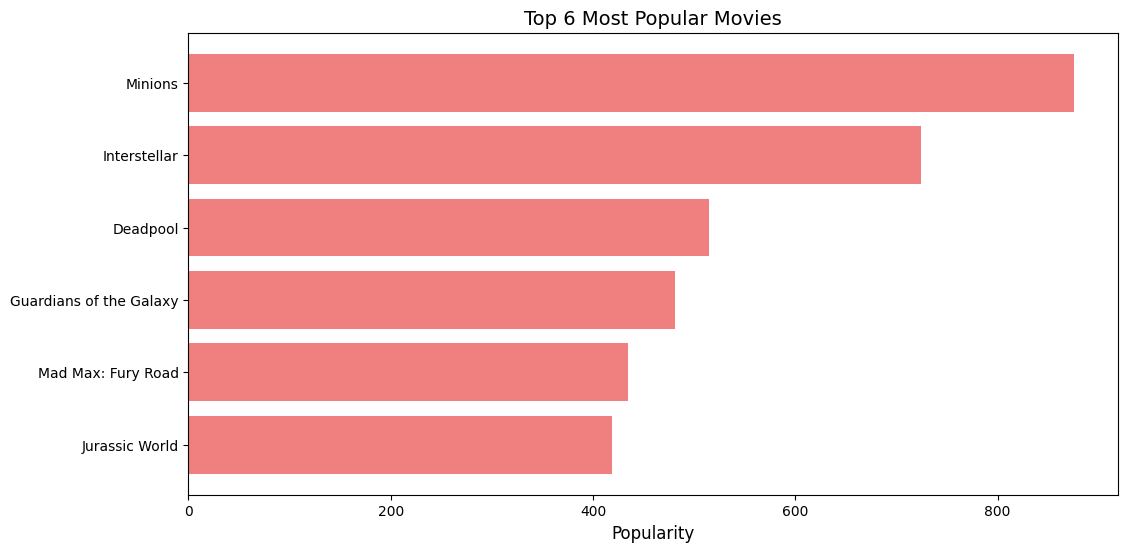

In [ ]:
# Mengurutkan data film berdasarkan popularitas tertinggi
sorted_movies_by_popularity = movies_df.sort_values('popularity', ascending=False)

# Menentukan ukuran plot (lebar dan tinggi)
plt.figure(figsize=(12, 6))

# Membuat diagram batang horizontal untuk 6 film terpopuler
plt.barh(sorted_movies_by_popularity['title'].head(6),
         sorted_movies_by_popularity['popularity'].head(6),
         align='center', color='lightcoral')

# Membalikkan sumbu y agar film dengan popularitas tertinggi berada di atas
plt.gca().invert_yaxis()

# Menambahkan label untuk sumbu X (Popularitas)
plt.xlabel("Popularity", fontsize=12)

# Menambahkan judul pada grafik
plt.title("Top 6 Most Popular Movies", fontsize=14)

# Menampilkan grafik
plt.show()

In [ ]:
movies_df['overview'].head(5)

0    In the 22nd century, a paraplegic Marine is di...
1    Captain Barbossa, long believed to be dead, ha...
2    A cryptic message from Bond’s past sends him o...
3    Following the death of District Attorney Harve...
4    John Carter is a war-weary, former military ca...
Name: overview, dtype: object

In [ ]:
# Inisialisasi objek TF-IDF Vectorizer dengan menghilangkan stop words dalam bahasa Inggris
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Mengganti nilai NaN dalam kolom 'overview' dengan string kosong untuk menghindari error
movies_df['overview'] = movies_df['overview'].fillna('')

# Membangun matriks TF-IDF dengan menyesuaikan dan mentransformasikan teks dalam kolom 'overview'
tfidf_matrix = tfidf_vectorizer.fit_transform(movies_df['overview'])

# Menampilkan dimensi dari matriks TF-IDF yang telah dibuat
print(f"Dimensi matriks TF-IDF: {tfidf_matrix.shape}")

Dimensi matriks TF-IDF: (4803, 20978)


In [ ]:
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [ ]:
# Menghitung matriks kesamaan kosinus antara dokumen
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

In [ ]:
# Membuat peta balik (reverse map) antara indeks dan judul film
indices = pd.Series(movies_df.index, index=movies_df['title']).drop_duplicates()

In [ ]:
# Daftar fitur yang ingin diubah dari string menjadi objek Python
features = ['cast', 'crew', 'keywords', 'genres']

# Melakukan parsing string yang berisi fitur-fitur menjadi objek Python yang sesuai
for feature in features:
    # Menggunakan literal_eval untuk mengonversi string menjadi list atau dictionary
    movies_df[feature] = movies_df[feature].apply(literal_eval)

In [ ]:
# Fungsi untuk mendapatkan nama sutradara dari fitur crew
# Jika sutradara tidak ditemukan, akan mengembalikan NaN
def get_director(x):
    # Mengiterasi setiap elemen dalam crew
    for i in x:
        # Memeriksa jika peran dalam crew adalah 'Director'
        if i['job'] == 'Director':
            return i['name']
    # Jika tidak ditemukan sutradara, mengembalikan NaN
    return np.nan

In [ ]:
# Fungsi untuk mengembalikan 3 elemen teratas dari list, atau seluruh list jika jumlah elemen kurang dari 3
def get_list(x):
    # Memeriksa apakah x adalah sebuah list
    if isinstance(x, list):
        # Membuat daftar nama dengan mengambil elemen 'name' dari setiap dictionary dalam list
        names = [i['name'] for i in x]

        # Memeriksa apakah jumlah elemen lebih dari 3. Jika ya, hanya mengembalikan 3 elemen pertama
        if len(names) > 3:
            names = names[:3]
        return names

    # Jika x bukan list atau data rusak, mengembalikan list kosong
    return []

In [ ]:
# Menambahkan fitur baru untuk sutradara, cast, genre, dan kata kunci dalam bentuk yang sesuai

# Menggunakan fungsi get_director untuk mengambil nama sutradara dari kolom 'crew'
movies_df['director'] = movies_df['crew'].apply(get_director)

# Daftar fitur yang ingin diolah
features = ['cast', 'keywords', 'genres']

# Iterasi untuk setiap fitur dalam daftar 'features'
for feature in features:
    # Menggunakan fungsi get_list untuk mengolah data list dalam setiap fitur
    movies_df[feature] = movies_df[feature].apply(get_list)


In [ ]:
# Menampilkan fitur baru untuk 3 film pertama dalam dataset
movies_df[['title', 'cast', 'director', 'keywords', 'genres']].head(3)

,title,cast,director,keywords,genres
0,Avatar,"[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron,"[culture clash, future, space war]","[Action, Adventure, Fantasy]"
1,Pirates of the Caribbean: At World's End,"[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski,"[ocean, drug abuse, exotic island]","[Adventure, Fantasy, Action]"
2,Spectre,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes,"[spy, based on novel, secret agent]","[Action, Adventure, Crime]"


In [ ]:
# Fungsi untuk mengubah semua string menjadi huruf kecil dan menghapus spasi pada nama
def clean_data(x):
    # Mengecek jika x adalah list
    if isinstance(x, list):
        # Mengubah semua elemen dalam list menjadi huruf kecil dan menghapus spasi
        return [str.lower(i.replace(" ", "")) for i in x]
    else:
        # Jika x adalah string, mengubahnya menjadi huruf kecil dan menghapus spasi
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        else:
            # Jika x bukan string atau list, mengembalikan string kosong
            return ''

In [ ]:
# Menerapkan fungsi clean_data ke fitur yang ada dalam DataFrame
features = ['cast', 'keywords', 'director', 'genres']

# Iterasi melalui setiap fitur yang ada dalam list 'features'
for feature in features:
    # Menerapkan fungsi clean_data pada setiap elemen dalam kolom feature
    movies_df[feature] = movies_df[feature].apply(clean_data)

In [ ]:
# Fungsi untuk membuat 'soup' dari fitur keywords, cast, director, dan genres
def create_soup(x):
    # Menggabungkan keywords, cast, director, dan genres menjadi satu string
    return ' '.join(x['keywords']) + ' ' + ' '.join(x['cast']) + ' ' + x['director'] + ' ' + ' '.join(x['genres'])

# Menerapkan fungsi create_soup ke setiap baris DataFrame untuk membuat kolom 'soup'
movies_df['soup'] = movies_df.apply(create_soup, axis=1)

In [ ]:
# Membuat objek CountVectorizer dengan mengabaikan stop words bahasa Inggris
count = CountVectorizer(stop_words='english')

# Membuat matriks hitung dari kolom 'soup' yang berisi gabungan fitur keywords, cast, director, dan genres
count_matrix = count.fit_transform(movies_df['soup'])

In [ ]:
# Menghitung matriks Cosine Similarity berdasarkan matriks hitung (count_matrix)
cosine_sim2 = cosine_similarity(count_matrix, count_matrix)


In [ ]:
# Mereset indeks dari DataFrame utama movies_df
movies_df = movies_df.reset_index()

# Membuat pemetaan balik (reverse mapping) antara indeks dan judul film
indices = pd.Series(movies_df.index, index=movies_df['title'])


## **Modeling Content Based Filtering**

Pendekatan ini menggunakan Content-Based Filtering untuk memberikan rekomendasi film berdasarkan kemiripan kontennya. Model ini membandingkan deskripsi film dan fitur lainnya, seperti sutradara, pemeran, genre, dan kata kunci, untuk menemukan film yang memiliki karakteristik serupa.

Data diformat dengan membersihkan teks, mengubah string menjadi daftar untuk fitur seperti genre dan pemeran, serta menggabungkan informasi relevan ke dalam satu kolom ('soup'). Dua teknik utama yang digunakan adalah TF-IDF Vectorizer untuk mengolah sinopsis film dan CountVectorizer untuk fitur tambahan. Dengan menggunakan Cosine Similarity, sistem dapat menghitung tingkat kemiripan antar film.

Model ini memungkinkan pengguna mendapatkan rekomendasi film yang relevan berdasarkan film yang sudah mereka tonton atau pilih sebelumnya, dengan hasil yang lebih akurat dibandingkan pendekatan berbasis metadata sederhana.

In [ ]:
def get_recommendation(judul, cosine_sim=cosine_sim2, k=10):
    # Ambil indeks dari film input
    idx = indices[judul]

    # Ambil skor kemiripan dan urutkan secara menurun
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:k+1]  # Ambil k film yang paling mirip (tanpa film itu sendiri)

    # Ekstrak indeks dan skor kemiripan dari hasil
    movie_indices = [i[0] for i in sim_scores]
    movie_scores = [i[1] for i in sim_scores]

    # Ambil genre dari film input
    input_genres_raw = movies_df.loc[idx, 'genres']
    input_genres = set(input_genres_raw) if isinstance(input_genres_raw, list) else set()

    # Inisialisasi list untuk menyimpan hasil
    titles, predicted_genres, matched_genres = [], [], []
    relevance_scores = []  # Digunakan untuk perhitungan NDCG

    # Hitung metrik untuk setiap film rekomendasi
    for i in movie_indices:
        # Ambil genre dari film hasil rekomendasi
        rec_genres_raw = movies_df.loc[i, 'genres']
        rec_genres = set(rec_genres_raw) if isinstance(rec_genres_raw, list) else set()

        # Hitung irisan (genre yang cocok)
        intersection = input_genres & rec_genres

        # Hitung skor relevansi berdasarkan jumlah genre yang cocok
        relevance_score = len(intersection)

        # Simpan hasil
        titles.append(movies_df.loc[i, 'title'])
        predicted_genres.append(list(rec_genres))
        matched_genres.append(list(intersection))
        relevance_scores.append(relevance_score)

    # Hitung NDCG@K (Normalized Discounted Cumulative Gain)
    ideal_relevance = sorted(relevance_scores, reverse=True)
    ndcg = ndcg_score([ideal_relevance], [relevance_scores])

    # Buat DataFrame hasil rekomendasi
    recommendations = pd.DataFrame({
        'Title': titles,
        'Similarity Score': movie_scores,
        'Predicted Genre': predicted_genres,
        'Matched Genres': matched_genres,
        'Relevance Score': relevance_scores,  # Jumlah genre yang cocok
        'Input Genre': [list(input_genres)] * len(movie_indices)
    })

    # Tampilkan metrik evaluasi
    print(f"Metrik Evaluasi untuk '{judul}':")
    print(f"- NDCG@{k}: {ndcg:.4f}")

    return recommendations


In [ ]:
get_recommendation('The Dark Knight Rises', cosine_sim2).loc[:]

Metrik Evaluasi untuk 'The Dark Knight Rises':
- NDCG@10: 0.9678


,Title,Similarity Score,Predicted Genre,Matched Genres,Relevance Score,Input Genre
0,The Dark Knight,0.700000,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
1,Batman Begins,0.700000,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
2,Amidst the Devil's Wings,0.547723,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
3,The Prestige,0.400000,"[drama, mystery, thriller]",[drama],1,"[drama, crime, action]"
4,Romeo Is Bleeding,0.400000,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
5,Black November,0.358569,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
6,Takers,0.335410,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
7,Faster,0.335410,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"
8,Catwoman,0.316228,"[crime, action]","[crime, action]",2,"[drama, crime, action]"
9,Gangster Squad,0.316228,"[drama, crime, action]","[drama, crime, action]",3,"[drama, crime, action]"


In [ ]:
get_recommendation('The Godfather', cosine_sim2).loc[:]

Metrik Evaluasi untuk 'The Godfather':
- NDCG@10: 0.9791


,Title,Similarity Score,Predicted Genre,Matched Genres,Relevance Score,Input Genre
0,The Godfather: Part III,0.527046,"[drama, crime, thriller]","[drama, crime]",2,"[drama, crime]"
1,The Godfather: Part II,0.421637,"[drama, crime]","[drama, crime]",2,"[drama, crime]"
2,Amidst the Devil's Wings,0.384900,"[drama, crime, action]","[drama, crime]",2,"[drama, crime]"
3,The Son of No One,0.377964,"[drama, crime, thriller]","[drama, crime]",2,"[drama, crime]"
4,Apocalypse Now,0.333333,"[drama, war]",[drama],1,"[drama, crime]"
5,The Cotton Club,0.316228,"[drama, music, crime]","[drama, crime]",2,"[drama, crime]"
6,The Talented Mr. Ripley,0.316228,"[drama, crime, thriller]","[drama, crime]",2,"[drama, crime]"
7,The Rainmaker,0.316228,"[drama, crime, thriller]","[drama, crime]",2,"[drama, crime]"
8,Donnie Brasco,0.316228,"[drama, crime, thriller]","[drama, crime]",2,"[drama, crime]"
9,Scarface,0.316228,"[drama, crime, action]","[drama, crime]",2,"[drama, crime]"


## **Modeling Collaborative Based Filtering**

Pendekatan ini menggunakan Collaborative Filtering untuk memberikan rekomendasi berdasarkan interaksi pengguna dengan film. Model ini memanfaatkan pola rating yang diberikan oleh pengguna lain dengan preferensi serupa untuk memprediksi film yang mungkin disukai oleh pengguna tertentu.

Dataset diproses dengan membangun matriks pengguna-film yang berisi rating yang diberikan oleh masing-masing pengguna. Teknik Singular Value Decomposition (SVD) digunakan untuk mendekomposisi matriks ini dan mengidentifikasi pola tersembunyi dalam preferensi pengguna.

Evaluasi model dilakukan dengan teknik cross-validation menggunakan Root Mean Square Error (RMSE) dan Mean Absolute Error (MAE) untuk mengukur akurasi prediksi. Setelah model dilatih, sistem dapat memberikan rekomendasi film kepada pengguna berdasarkan prediksi rating tertinggi untuk film yang belum mereka tonton.

Pendekatan ini sangat efektif karena mampu menangkap hubungan implisit antar pengguna dan film, memungkinkan sistem untuk merekomendasikan film yang relevan meskipun tidak memiliki metadata yang sama dengan film yang sudah ditonton oleh pengguna.


In [ ]:
# Membuat objek Reader untuk membaca data rating
reader = Reader()

# Memuat dataset dari DataFrame (pastikan ratings_df sudah tersedia)
data = Dataset.load_from_df(ratings_df[['userId', 'movieId', 'rating']], reader)

In [ ]:
# Membagi dataset menjadi beberapa lipatan (folds) untuk cross-validation
svd = SVD()
# Melakukan cross-validation untuk mengukur akurasi model dengan 5 fold
cross_validate(svd, data, cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8991  0.9058  0.8924  0.8937  0.9003  0.8983  0.0048  
MAE (testset)     0.6920  0.6963  0.6881  0.6882  0.6925  0.6914  0.0031  
Fit time          1.35    1.47    1.46    1.47    1.48    1.45    0.05    
Test time         0.10    0.11    0.27    0.11    0.11    0.14    0.06    


{'test_rmse': array([0.89914465, 0.90575908, 0.8924171 , 0.8936898 , 0.90031506]),
 'test_mae': array([0.69199974, 0.69632887, 0.6880823 , 0.68823013, 0.69249493]),
 'fit_time': (1.351928949356079,
  1.4651832580566406,
  1.4624958038330078,
  1.4699411392211914,
  1.481379747390747),
 'test_time': (0.10464906692504883,
  0.10818886756896973,
  0.26520752906799316,
  0.10611534118652344,
  0.11444568634033203)}

In [ ]:
# Melatih model SVD dengan dataset penuh
trainset = data.build_full_trainset()
svd.fit(trainset)

In [ ]:
def get_user_recommendations(user_id, svd_model, top_n=10):
    # 1. Get movies watched by user
    movies_watched = ratings_df[ratings_df['userId'] == user_id]

    if movies_watched.empty:
        print(f"User {user_id} has not watched any movies.")
        return None, None

    # 2. Process watched movies
    watched_info = movies_watched.merge(movies_df, left_on='movieId', right_on='id', how='left')
    watched_info = watched_info.drop_duplicates(subset=['title'])
    watched_info['rating'] = pd.to_numeric(watched_info['rating'], errors='coerce')
    watched_info = watched_info.sort_values(by='rating', ascending=False).head(11)

    # Filter out NaN titles for watched movies
    watched_info = watched_info[watched_info['title'].notna()]

    # 3. Create watched movies DataFrame
    watched_df = pd.DataFrame({
        'Title': watched_info['title'],
        'Genres': watched_info['genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else 'Unknown'),
        'User Rating': watched_info['rating']
    })

    # 4. Get movies not watched
    movies_not_watched = movies_df[~movies_df['id'].isin(movies_watched['movieId'])]

    # 5. Predict ratings for unwatched movies
    predicted_ratings = [svd_model.predict(user_id, movie_id).est for movie_id in movies_not_watched['id']]
    movies_not_watched['predicted_rating'] = predicted_ratings

    # 6. Get top recommendations (filter NaN titles and fix typo in 'predicted_rating')
    movies_not_watched = movies_not_watched[movies_not_watched['title'].notna()]
    top_recommendations = movies_not_watched.sort_values('predicted_rating', ascending=False).head(top_n)

    # 7. Create recommendations DataFrame
    recommendations_df = pd.DataFrame({
        'Title': top_recommendations['title'],
        'Genres': top_recommendations['genres'].apply(lambda x: ', '.join(x) if isinstance(x, list) else 'Unknown'),
        'Predicted Rating': top_recommendations['predicted_rating']
    })

    return watched_df, recommendations_df

In [ ]:
# Contoh penggunaan
user_id = 2
watched_movies, recommended_movies = get_user_recommendations(user_id, svd)

# Tampilkan hasil
print(f"\n{'='*50}")
print(f"Film yang sudah ditonton oleh User {user_id}")
print('='*50)
watched_movies.loc[:]


Film yang sudah ditonton oleh User 2


/tmp/ipykernel_31/3331866934.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies_not_watched['predicted_rating'] = predicted_ratings


,Title,Genres,User Rating
71,The Conversation,"crime, drama, mystery",5.0
70,The Hours,drama,5.0
65,"Monsters, Inc.","animation, comedy, family",5.0
29,Terminator 3: Rise of the Machines,"action, thriller, sciencefiction",4.0
50,My Own Private Idaho,"drama, romance",4.0
48,Romeo + Juliet,"drama, romance",4.0
55,Reservoir Dogs,"crime, thriller",4.0
56,Love Actually,"comedy, romance, drama",4.0
36,The Devil Wears Prada,"comedy, drama, romance",4.0
57,Notting Hill,"romance, comedy, drama",4.0


In [ ]:
print(f"\n{'='*50}")
print(f"Rekomendasi Film untuk User {user_id}")
print('='*50)
recommended_movies.loc[:]


Rekomendasi Film untuk User 2


,Title,Genres,Predicted Rating
1850,Scarface,"action, crime, drama",4.326152
1666,The Good Thief,"crime, drama, thriller",4.315547
952,Beverly Hills Cop III,"action, comedy, crime",4.278468
1145,The Sixth Sense,"mystery, thriller, drama",4.260774
43,Terminator Salvation,"action, sciencefiction, thriller",4.233225
1748,Notes on a Scandal,"drama, romance",4.219549
1053,Galaxy Quest,"comedy, family, sciencefiction",4.214713
970,Hannibal Rising,"crime, drama, thriller",4.185182
452,Space Jam,"animation, comedy, drama",4.176195
425,Mission: Impossible,"adventure, action, thriller",4.166978


## **Kesimpulan Sistem Rekomendasi Film**

### **1. Content-Based Filtering**
- **Metode**: Cosine Similarity berdasarkan metadata film  
- **Evaluasi**: NDCG@10 (Normalized Discounted Cumulative Gain)  
  - 🎬 The Dark Knight Rises: **0.9678**  
  - 🎬 The Godfather: **0.9791**  
- **Interpretasi**:  
  - Nilai ≈1.0 menunjukkan rekomendasi sangat relevan  

### **2. Collaborative Filtering (SVD)**  
- **Metode**: Matrix Factorization dengan SVD  
- **Evaluasi**:  
  - 📉 RMSE: **0.8959**  
  - 📊 MAE: **0.6893**  
- **Kelebihan**: Personalisasi berdasarkan riwayat rating user  

### **Perbandingan Performa**  
| Kriteria               | Content-Based       | Collaborative      |
|------------------------|---------------------|--------------------|
| **Metrik Evaluasi**    | NDCG@10 (0.96-0.97) | RMSE (0.89)        |
| **Kekuatan**           | Relevansi konten    | Personalisasi user |
| **Batasan**            | Cold-start problem  | Sparsity data      |

### **Rekomendasi Pengembangan**  
1. **Hybrid System**: Gabungkan kedua metode untuk:  
   - Relevansi konten (Content-Based)  
   - Personalisasi (Collaborative)  
2. **Improvement**:  
   - Tambah fitur film (sutradara, aktor)  
   - Gunakan deep learning untuk embedding  